In [37]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from olist.data import Olist
from olist.seller import Seller

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Satıcılar

🎯 Amacımız, diğerlerine göre tekrarlı olarak düşük performans gösteren satıcıları bulmak ve nedenini anlamaktır.  
Bu, Olist'in gelecekte kâr marjını artırmaya yönelik önerilerimizi şekillendirmemize yardımcı olacaktır.

## 1 - `olist/seller.py`  

`order.py` ile benzer bir süreçte, size `olist/seller.py` modülünü sunduk; içinde `Seller` sınıfı ve `Seller().get_training_data` yöntemi bulunuyor. Bu yöntem aşağıdaki özellikleri içeren bir DataFrame döndürür:

| feature_name | type | açıklama |
| --- | --- | --- |
| `seller_id` | str | satıcının benzersiz kimliği (UNIQUE) |
| `seller_city` | str | satıcının bulunduğu şehir |
| `seller_state` | str | satıcının bulunduğu eyalet |
| `delay_to_carrier` | float | sipariş, `shipping_limit_date`'den önce teslim edildiyse 0 döner; aksi takdirde gecikme süresini verir |
| `wait_time` | float | satıcı başına ortalama teslimat süresi (bekleme süresi) |
| `date_first_sale` | datetime | Olist üzerinde yapılan ilk satışın tarihi |
| `date_last_sale` | datetime | Olist üzerindeki son satışın tarihi |
| `months_on_olist` | float | Olist'te geçirilen yaklaşık ay sayısı |
| `share_of_five_stars` | float | satıcının yer aldığı siparişlerdeki beş yıldız değerlendirmelerinin oranı |
| `share_of_one_stars` | float | satıcının yer aldığı siparişlerdeki bir yıldız değerlendirmelerinin oranı |
| `review_score` | float | satıcının yer aldığı siparişler için ortalama değerlendirme puanı |
| `n_orders` | int | satıcının yer aldığı benzersiz sipariş sayısı |
| `quantity` | int | bu satıcı tarafından satılan toplam ürün adedi |
| `quantity_per_order` | float | bu satıcı için sipariş başına ortalama ürün sayısı |
| `sales` | float | bu satıcı ile ilişkili toplam satış tutarı (kargo hariç), BRL cinsinden |

❓ **Aşağıya yeni sınıfınızı import edin ve eğitim veri çerçevenizi inceleyin!** Kodları incelemek için zaman ayırın ve sizin için tam olarak nelerin hesaplandığını anlayın.

In [38]:
from olist.seller import Seller
sellers = Seller().get_training_data()
sellers.head()

,seller_city,seller_id,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,n_orders,quantity,quantity_per_order,sales,share_of_five_stars,share_of_one_stars,review_score
0,campinas,3442f8959a84dea7ee197c632cb2df15,SP,0.000000,13.018588,2017-05-05 16:25:11,2017-08-30 12:50:19,4.0,3,3,1.000,218.70,0.333333,0.333333,3.00
1,mogi guacu,d1b65fc7debc3361ea86b5f14c68d2e2,SP,0.000000,9.065716,2017-03-29 02:10:34,2018-06-06 20:15:21,14.0,40,41,1.025,11703.07,0.725000,0.050000,4.55
2,rio de janeiro,ce3ad9de960102d0677a81f5d0bb7b2d,RJ,0.000000,4.042292,2018-07-30 12:44:49,2018-07-30 12:44:49,0.0,1,1,1.000,158.00,1.000000,0.000000,5.00
3,sao paulo,c0f3eea2e14555b6faeea3dd58c1b1c3,SP,0.000000,5.667187,2018-08-03 00:44:08,2018-08-03 00:44:08,0.0,1,1,1.000,79.99,1.000000,0.000000,5.00
4,braganca paulista,51a04a8a6bdcb23deccc82b0b80742cf,SP,3.353727,35.314861,2017-11-14 12:15:25,2017-11-14 12:15:25,0.0,1,1,1.000,167.99,0.000000,1.000000,1.00


🤔 Her satıcı için henüz hesaplanması gereken bir şey kaldı:
- Aşırı yüksek değerlendirmelerin oranı (`share_of_five_stars`) ve aşırı düşük değerlendirmelerin oranı (`share_of_one_stars`)
- (ortalama) `review_score`

😱 Düşük puanlı her sipariş Olist'in itibarına olumsuz etki yapar; bu etki `cost_of_review` ile modellenir.

Bu, daha sonra her satıcı için toplam `cost_of_review`'u hesaplamamıza yardımcı olacak!

❓ **Sizin doldurmanız gereken son metod: `get_review_score()`'u implemente edin.**

In [39]:
from olist.seller import Seller
import pandas as pd

# Training data'yı al
df = Seller().get_training_data()

# 1️⃣ Hiç siparişi olmayan seller'ları çıkar
df = df[df["n_orders"] > 0]

# 2️⃣ Güvenlik: seller_id unique mi?
df = df.drop_duplicates(subset="seller_id")

df

,seller_city,seller_id,seller_state,delay_to_carrier,wait_time,date_first_sale,date_last_sale,months_on_olist,n_orders,quantity,quantity_per_order,sales,share_of_five_stars,share_of_one_stars,review_score
0,campinas,3442f8959a84dea7ee197c632cb2df15,SP,0.000000,13.018588,2017-05-05 16:25:11,2017-08-30 12:50:19,4.0,3,3,1.000000,218.70,0.333333,0.333333,3.00
1,mogi guacu,d1b65fc7debc3361ea86b5f14c68d2e2,SP,0.000000,9.065716,2017-03-29 02:10:34,2018-06-06 20:15:21,14.0,40,41,1.025000,11703.07,0.725000,0.050000,4.55
2,rio de janeiro,ce3ad9de960102d0677a81f5d0bb7b2d,RJ,0.000000,4.042292,2018-07-30 12:44:49,2018-07-30 12:44:49,0.0,1,1,1.000000,158.00,1.000000,0.000000,5.00
3,sao paulo,c0f3eea2e14555b6faeea3dd58c1b1c3,SP,0.000000,5.667187,2018-08-03 00:44:08,2018-08-03 00:44:08,0.0,1,1,1.000000,79.99,1.000000,0.000000,5.00
4,braganca paulista,51a04a8a6bdcb23deccc82b0b80742cf,SP,3.353727,35.314861,2017-11-14 12:15:25,2017-11-14 12:15:25,0.0,1,1,1.000000,167.99,0.000000,1.000000,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2962,sarandi,98dddbc4601dd4443ca174359b237166,PR,0.000000,8.230822,2018-07-14 03:10:19,2018-07-23 15:34:03,0.0,2,2,1.000000,158.00,1.000000,0.000000,5.00
2963,palhoca,f8201cab383e484733266d1906e2fdfa,SC,0.000000,13.045797,2017-06-17 15:30:11,2018-08-11 19:55:17,14.0,10,10,1.000000,889.00,0.500000,0.100000,4.10
2964,sao paulo,74871d19219c7d518d0090283e03c137,SP,0.000000,3.606625,2018-04-05 17:09:46,2018-08-21 19:25:15,5.0,6,7,1.166667,550.04,1.000000,0.000000,5.00
2965,pelotas,e603cf3fec55f8697c9059638d6c8eb5,RS,0.000000,6.657634,2017-02-09 02:43:17,2017-06-16 17:30:16,4.0,8,11,1.375000,297.00,0.500000,0.000000,4.25


🧪 Kodunuzu aşağıda test edin

In [40]:
tmp = Seller().get_training_data()
tmp.columns

Index(['seller_city', 'seller_id', 'seller_state', 'delay_to_carrier',
       'wait_time', 'date_first_sale', 'date_last_sale', 'months_on_olist',
       'n_orders', 'quantity', 'quantity_per_order', 'sales',
       'share_of_five_stars', 'share_of_one_stars', 'review_score'],
      dtype='object')

In [41]:
from nbresult import ChallengeResult
from olist.seller import Seller

tmp = Seller().get_training_data()
tmp = tmp[tmp["n_orders"] > 0]

result = ChallengeResult(
    "seller",
    shape=tmp.shape,
    median=tmp["review_score"].median(),
    columns=tmp.columns,
)

result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gizemtotkanli/.pyenv/versions/workintech_current/bin/python
cachedir: .pytest_cache
rootdir: /Users/gizemtotkanli/code/totkanligizem/03-Decision-Science/02-Linear-Regression/data-sellers/tests
plugins: dash-3.3.0, anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_seller.py::TestSeller::test_column_names PASSED                     [ 33%]
test_seller.py::TestSeller::test_median_review_score PASSED              [ 66%]
test_seller.py::TestSeller::test_shape PASSED                            [100%]

============================== 3 passed in 0.31s ===============================


💯 You can commit your code:

git add tests/seller.pickle

git commit -m 'Completed seller step'

git push origin master



💡 **Tam satır sayısını elde edemiyor musunuz?**
<details><summary>Fazladan 3 satır mı var?</summary>
Left veya right join mi yaptınız? Nedenini anlıyoruz; fakat burada sadece değerlendirme alan satıcılarla ilgileniyoruz; bu yüzden inner join kullandık.
</details>
<details><summary>2 satır mı eksik?</summary>
`Orders().get_training_data()`'ı mı kullandınız? Bu geçerli bir seçenek, fakat sadece değerlendirmelerle ilgileniyorsak biraz aşırı olabilir. O method birçok hesaplama yapar ve döndürdüğü sütunların çoğuna ihtiyaç duymuyoruz. İhtiyacımıza daha uygun başka bir `Order` methodu bulun.
</details>

⚠️ `olist` reposundaki `seller.py` dosyasına yaptığınız kod değişikliklerini commit etmeyi unutmayın!

## 2 - Satıcıları İnceleme

### (2.1) Görselleştirmeler

Bu satıcılar hakkında ilk ***`EDA - Keşifsel Veri Analizi`*** ile başlayalım.

👉 `sellers` için özet istatistiklere bakın. Satıcı başına siparişlerin medyanı nedir ❓

In [42]:
# Satıcı başına sipariş sayısının medyanı
sellers.describe()

median_n_orders = sellers["n_orders"].median()
median_n_orders

7.0

In [43]:
sellers["n_orders"].describe()

count    2967.000000
mean       33.650489
std       107.182856
min         1.000000
25%         2.000000
50%         7.000000
75%        23.000000
max      1854.000000
Name: n_orders, dtype: float64

👉 Bir sonraki adımda, veri setindeki her sayısal değişkenin dağılımını tek bir büyük görselde çizeceğiz. 

Kod size verildi, hücreyi çalıştırmanız yeterli.

- 👀 Herhangi bir aykırı değer fark ediyor musunuz?
- Sipariş sayısının dağılımı nasıl görünüyor ❓

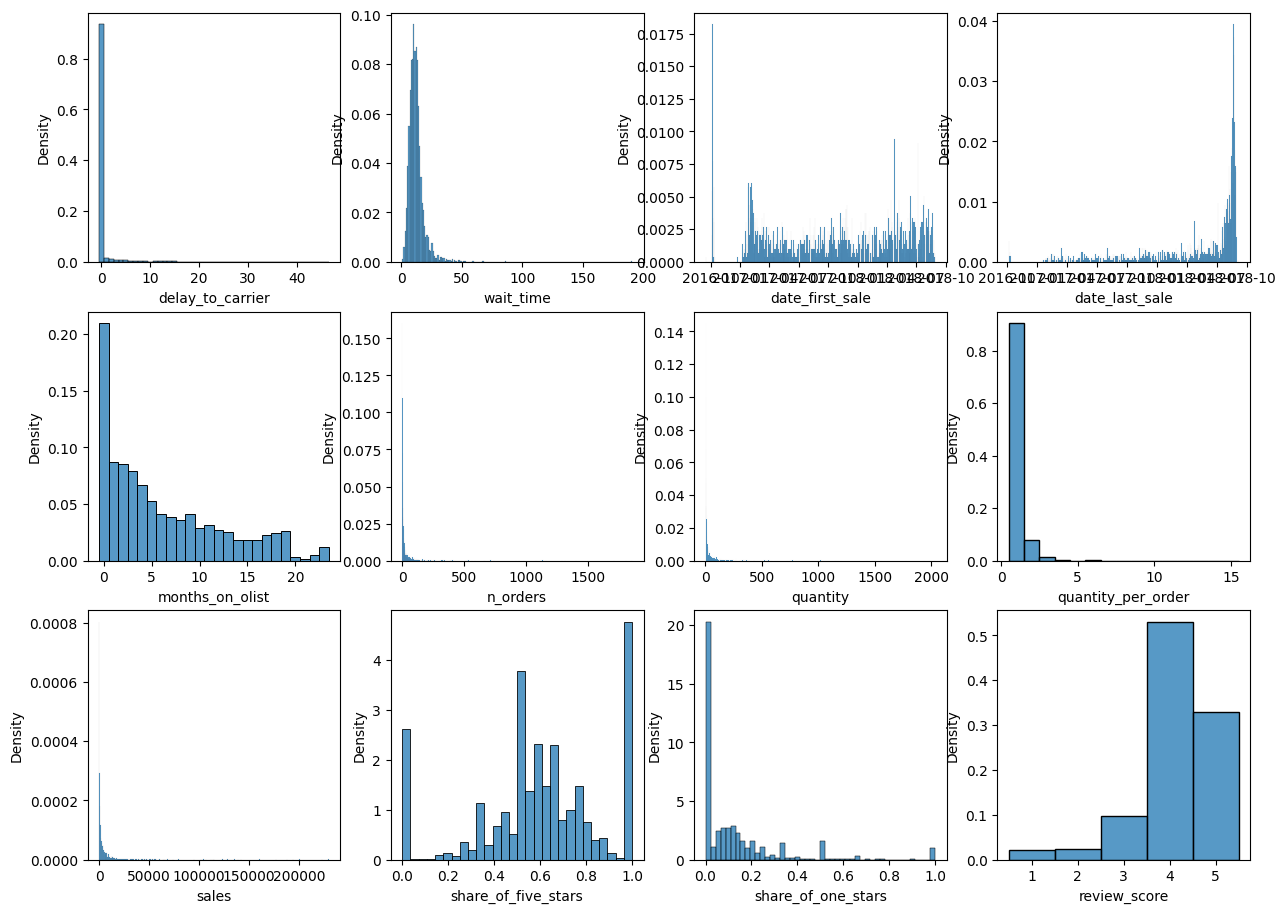

In [44]:
plt.figure(figsize=(15,11))
for (i, col) in enumerate(sellers.describe().columns):#["wait_time", "delay_to_carrier", "avg_review_score", "n_orders", "quantity", "price"]):
    plt.subplot(3,4,i+1)
    sns.histplot(sellers[col], kde=False, stat='density', discrete=[True,None][col in ['share_of_one_stars','share_of_five_stars','sales']]);

💡 Çok düşük değerlendirme puanlarına sahip bir grup satıcının öne çıktığı görünüyor!

📊 Grafiksel olarak inceleyelim:
- `plotly` kullanarak `delay_to_carrier` ile `wait_time` arasındaki ilişkiyi gösteren bir saçılma grafiği (scatterplot) oluşturuyoruz; kabarcık boyutunu satıcının toplam `sales`'i, rengini ise `review_score` belirliyor.

`plotly`'ı daha sonra detaylı göreceğiz; şimdilik aşağıdaki hücreyi çalıştırın.

In [45]:
import plotly.express as px
fig = px.scatter(data_frame = sellers[sellers['review_score'] < 4],
    x="wait_time",
    y="delay_to_carrier",
    size="sales",
    color="review_score",
    size_max = 60,
    opacity = 0.5
)
fig.show()

En kötü satıcıları bulmak için `x`, `y`, `color` ve `size` değerlerini değiştirmekten çekinmeyin.

### (2.2) `review_score`'u OLS ile modelleme

⚠️ Saçılma grafikleri veriyi görsel olarak analiz etmemizi sağlar, fakat sınırlamaları vardır: deneme-yanılma içerir ve ilişkileri yalnızca niteliksel değerlendiririz.

💡 **Satıcıların `review_score`** değişkenini açıklamak için daha sağlam bir yöntem, `statsmodels` içinde **çok değişkenli (multivariate) OLS** kullanarak çeşitli özelliklerin `review_score` üzerindeki etkisini modellemektir.

İstediğiniz sayısal özellikleri kullanarak bir OLS oluşturalım.

👉 Regresyon katsayılarını karşılaştırabilmek için önce aşağıdaki `standardize` fonksiyonunu kullanarak özelliklerinizi standardize edin.

In [46]:
def standardize(df, features):
    """Standardize specified numerical features in a DataFrame using z-score.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.
    features : list of str
        List of column names to standardize.

    Returns
    -------
    pandas.DataFrame
        A copy of the original dataframe where the specified features have been
        standardized to zero mean and unit variance. Other columns are left
        unchanged.
    """
    df_standardized = df.copy()
    mu = df[features].mean()
    sigma = df[features].std()
    df_standardized[features] = (df[features] - mu) / sigma
    return df_standardized

In [47]:
features = [
    "wait_time",
    "delay_to_carrier",
    "n_orders",
    "quantity_per_order",
    "sales",
    "months_on_olist",
    "share_of_one_stars",
    "share_of_five_stars",
]

In [48]:
def standardize(df, features):
    df_std = df.copy()
    df_std[features] = (df[features] - df[features].mean()) / df[features].std()
    return df_std

In [49]:
sellers_standardized = standardize(sellers, features)

👉 Sonraki adımda bir OLS modeli oluşturun ve fit edin.

In [50]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula=f"review_score ~ {' + '.join(features)}",
    data=sellers_standardized
).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.945
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     6371.
Date:                Sun, 04 Jan 2026   Prob (F-statistic):               0.00
Time:                        22:40:13   Log-Likelihood:                 753.61
No. Observations:                2967   AIC:                            -1489.
Df Residuals:                    2958   BIC:                            -1435.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               4.1015      0.003   1188.476      0.000       4.095       4.108
wait_time              -0.0127      0.004     -3.053      0.002      -0.021      -0.005
delay_to_carrier        0.0026      0.004      0.648      0.517      -0.005       0.010
n_orders               -0.0024      0.006     -0.414      0.679      -0.014       0.009
quantity_per_order     -0.0028      0.003     -0.814      0.416      -0.010       0.004
sales                   0.0018      0.006      0.310      0.757      -0.010       0.013
months_on_olist        -0.0016      0.004     -0.425      0.671      -0.009       0.006
share_of_one_stars     -0.4851      0.004   -113.328      0.000      -0.493      -0.477
share_of_five_stars     0.4078      0.004    101.183      0.000       0.400       0.416
==============================================================================
Omnibus:                     1942.378   Durbin-Watson:                   1.983
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            51975.184
Skew:                          -2.684   Prob(JB):                         0.00
Kurtosis:                      22.789   Cond. No.                         3.26
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

❓ En etkili özellikler hangileri?

👉 Sıralanmış katsayılarla bir 📊 `bar_plot` çizin.

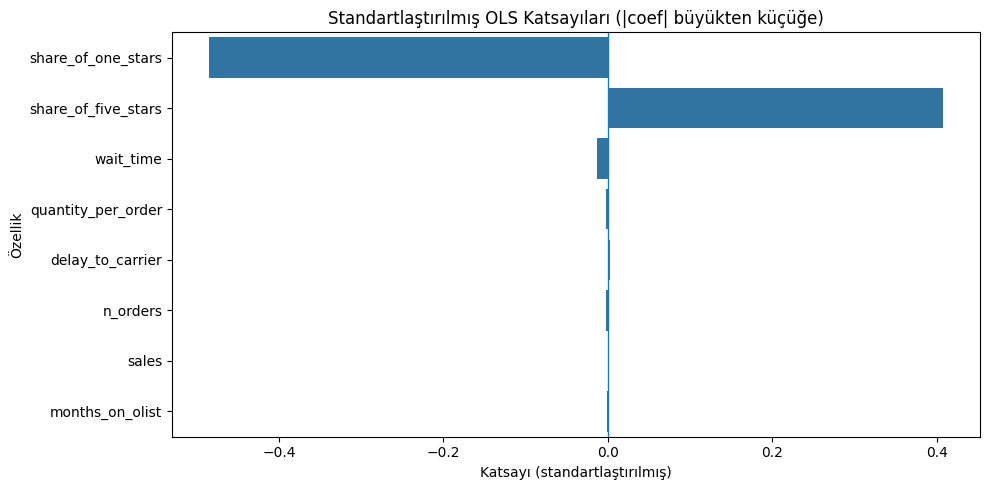

In [51]:
# Katsayıları al (Intercept hariç), mutlak değere göre sırala
coef = (
    model.params
    .drop("Intercept")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=coef.values, y=coef.index)
plt.title("Standartlaştırılmış OLS Katsayıları (|coef| büyükten küçüğe)")
plt.xlabel("Katsayı (standartlaştırılmış)")
plt.ylabel("Özellik")
plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.show()

👉 Son olarak modelinizin performansını (`R-squared`) ve `residuals`'ı inceleyin

In [52]:
print("R-squared:", model.rsquared)
print("Adj. R-squared:", model.rsquared_adj)

residuals = model.resid
print("\nResiduals summary:")
print(residuals.describe())

R-squared: 0.9451437293375109
Adj. R-squared: 0.9449953689029944

Residuals summary:
count    2.967000e+03
mean    -9.863660e-16
std      1.877267e-01
min     -1.555653e+00
25%     -2.684314e-02
50%      6.162807e-04
75%      6.380874e-02
max      5.164282e-01
dtype: float64


👉 Gerçek değerlendirme puanlarını ve modelin tahmin ettiği puanları aynı grafikte göstererek karşılaştırın.

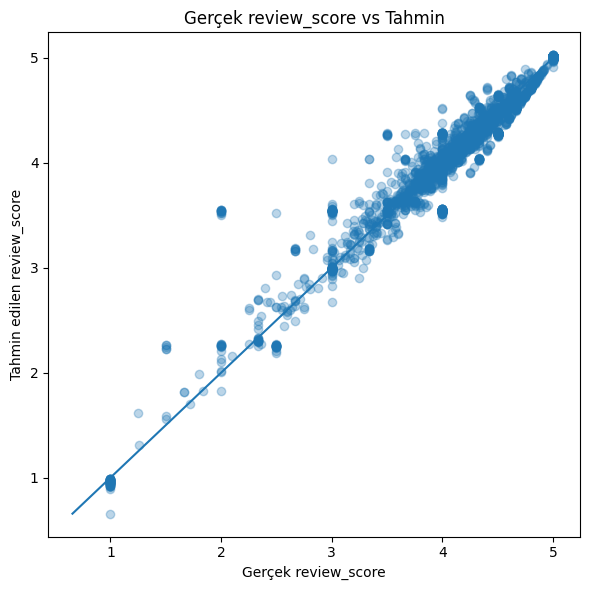

In [53]:
y_true = sellers_standardized["review_score"]
y_pred = model.predict(sellers_standardized)

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.title("Gerçek review_score vs Tahmin")
plt.xlabel("Gerçek review_score")
plt.ylabel("Tahmin edilen review_score")

# y=x referans çizgisi
min_v = min(y_true.min(), y_pred.min())
max_v = max(y_true.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v])

plt.tight_layout()
plt.show()

👉 Artıkları (residuals) görselleştirin

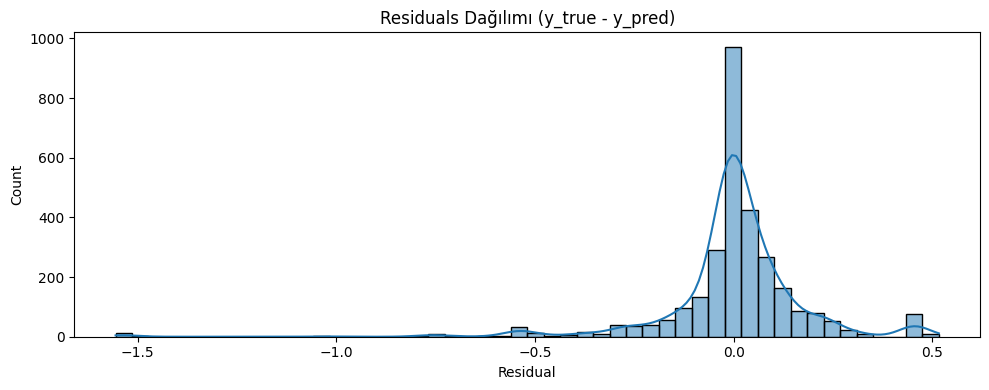

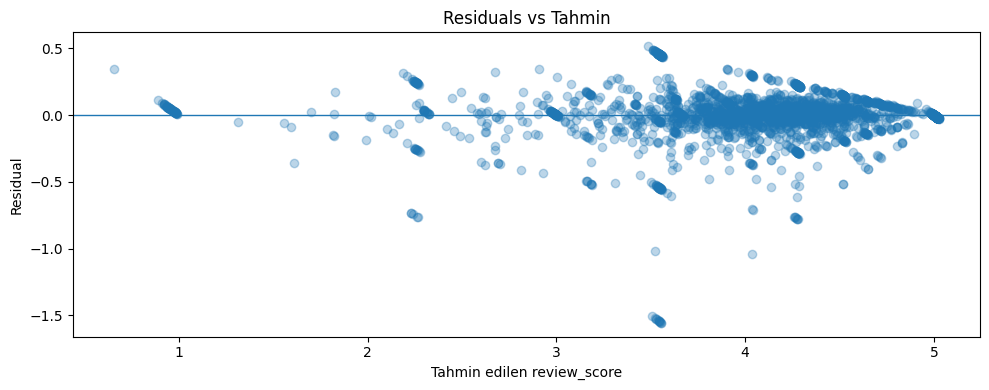

In [54]:
residuals = y_true - y_pred

plt.figure(figsize=(10, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residuals Dağılımı (y_true - y_pred)")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.title("Residuals vs Tahmin")
plt.xlabel("Tahmin edilen review_score")
plt.ylabel("Residual")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

### (2.3) Analize `seller_state` bilgisini ekleyin

❓ Henüz `seller_state` bilgisini kullanmadık.  
- Sadece `seller_state`'lere karşı `review_score`'u regresyonla modelleyen yeni bir OLS oluşturun.
- `olist/utils.py` içinde sizin için yazılmış olan `return_significative_coef(model)` fonksiyonunu kullanarak anlamlı (significant) özellikleri analiz edin.
- `review_score` açısından en iyi eyaletler hangileri?

<details>
    <summary>- İpuçları -</summary>
        
⚠️ Dikkat, `seller_state` kategorik bir özelliktir. 
    
💡 Formülde kategorik değişkenleri belirtmek için `C(a_cat_feature)` kullanın. Bu, her benzersiz kategori için bir boolean değişken (`is_cat_feature_xx`) oluşturacaktır.

</details>

In [55]:
import statsmodels.formula.api as smf
from olist.utils import return_significative_coef

model_state_only = smf.ols(
    formula="review_score ~ C(seller_state)",
    data=sellers
).fit()

model_state_only.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9825
Date:                Sun, 04 Jan 2026   Prob (F-statistic):              0.482
Time:                        22:40:14   Log-Likelihood:                -3542.7
No. Observations:                2967   AIC:                             7129.
Df Residuals:                    2945   BIC:                             7261.
Df Model:                          21                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 2.3333      0.802      2.911      0.004       0.762       3.905
C(seller_state)[T.BA]     1.7617      0.824      2.139      0.033       0.147       3.376
C(seller_state)[T.CE]     1.3461      0.834      1.613      0.107      -0.290       2.982
C(seller_state)[T.DF]     1.6988      0.815      2.085      0.037       0.101       3.296
C(seller_state)[T.ES]     2.0775      0.820      2.535      0.011       0.471       3.685
C(seller_state)[T.GO]     1.8102      0.812      2.230      0.026       0.218       3.402
C(seller_state)[T.MA]     1.6590      1.134      1.463      0.143      -0.564       3.882
C(seller_state)[T.MG]     1.8095      0.803      2.253      0.024       0.234       3.385
C(seller_state)[T.MS]     1.9545      0.878      2.226      0.026       0.233       3.676
C(seller_state)[T.MT]     1.8898      0.896      2.109      0.035       0.133       3.647
C(seller_state)[T.PA]     2.1667      1.134      1.911      0.056      -0.056       4.389
C(seller_state)[T.PB]     1.9306      0.866      2.230      0.026       0.233       3.628
C(seller_state)[T.PE]     1.7905      0.845      2.119      0.034       0.134       3.447
C(seller_state)[T.PI]     1.7500      1.134      1.544      0.123      -0.473       3.973
C(seller_state)[T.PR]     1.8291      0.803      2.278      0.023       0.255       3.403
C(seller_state)[T.RJ]     1.7656      0.804      2.196      0.028       0.189       3.342
C(seller_state)[T.RN]     2.1424      0.878      2.440      0.015       0.421       3.864
C(seller_state)[T.RO]     1.5208      0.982      1.549      0.121      -0.404       3.446
C(seller_state)[T.RS]     1.8154      0.805      2.256      0.024       0.237       3.393
C(seller_state)[T.SC]     1.8335      0.804      2.281      0.023       0.258       3.409
C(seller_state)[T.SE]     1.5167      0.982      1.545      0.122      -0.408       3.442
C(seller_state)[T.SP]     1.7395      0.802      2.170      0.030       0.167       3.312
==============================================================================
Omnibus:                      942.232   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2911.855
Skew:                          -1.626   Prob(JB):                         0.00
Kurtosis:                       6.603   Cond. No.                         308.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [56]:
return_significative_coef(model_state_only)

,variable,p_value,coef
0,Intercept,0.003630,2.333333
16,C(seller_state)[T.RN],0.014751,2.142381
4,C(seller_state)[T.ES],0.011300,2.077548
8,C(seller_state)[T.MS],0.026098,1.954474
11,C(seller_state)[T.PB],0.025835,1.930556
9,C(seller_state)[T.MT],0.035051,1.889815
19,C(seller_state)[T.SC],0.022605,1.833534
14,C(seller_state)[T.PR],0.022771,1.829067
18,C(seller_state)[T.RS],0.024153,1.815430
5,C(seller_state)[T.GO],0.025828,1.810196


☝️ Bazı eyaletlerin ortalama olarak diğerlerinden _anlamlı_ biçimde daha iyi değerlendirmelere sahip olduğu görülebilir.

🤔 Bu, daha düşük `quantity_per_order`, daha kısa `wait_time` veya `delay_to_carrier`'dan mı kaynaklanıyor? Yoksa elimizde olmayan başka faktörlerden mi?

❓ **`seller_state` etkisini diğerlerinden izole etmeye çalışın: OLS modelinize sürekli (continuous) diğer özellikleri ekleyin; `seller_state` artık istatistiksel olarak anlamlı olmayana kadar devam edin!**

In [57]:
model_state_wait = smf.ols(
    formula="review_score ~ C(seller_state) + wait_time",
    data=sellers
).fit()

model_state_wait.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     29.28
Date:                Sun, 04 Jan 2026   Prob (F-statistic):          1.52e-109
Time:                        22:40:14   Log-Likelihood:                -3259.5
No. Observations:                2967   AIC:                             6565.
Df Residuals:                    2944   BIC:                             6703.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.6120      0.734      6.280      0.000       3.172       6.052
C(seller_state)[T.BA]     0.2425      0.751      0.323      0.747      -1.230       1.715
C(seller_state)[T.CE]     0.0006      0.760      0.001      0.999      -1.490       1.492
C(seller_state)[T.DF]     0.0465      0.744      0.062      0.950      -1.412       1.505
C(seller_state)[T.ES]     0.3915      0.748      0.523      0.601      -1.076       1.858
C(seller_state)[T.GO]     0.2174      0.741      0.294      0.769      -1.235       1.670
C(seller_state)[T.MA]     0.2251      1.032      0.218      0.827      -1.799       2.249
C(seller_state)[T.MG]     0.1390      0.733      0.190      0.850      -1.299       1.577
C(seller_state)[T.MS]     0.2176      0.801      0.272      0.786      -1.354       1.789
C(seller_state)[T.MT]     0.2926      0.817      0.358      0.720      -1.310       1.895
C(seller_state)[T.PA]     0.5275      1.033      0.511      0.609      -1.497       2.552
C(seller_state)[T.PB]     0.2406      0.790      0.305      0.761      -1.308       1.790
C(seller_state)[T.PE]     0.1604      0.771      0.208      0.835      -1.351       1.672
C(seller_state)[T.PI]     0.1281      1.033      0.124      0.901      -1.897       2.153
C(seller_state)[T.PR]     0.1195      0.733      0.163      0.871      -1.318       1.557
C(seller_state)[T.RJ]     0.0454      0.734      0.062      0.951      -1.394       1.485
C(seller_state)[T.RN]     0.4376      0.801      0.546      0.585      -1.133       2.009
C(seller_state)[T.RO]     0.0561      0.894      0.063      0.950      -1.698       1.810
C(seller_state)[T.RS]     0.1776      0.735      0.242      0.809      -1.263       1.618
C(seller_state)[T.SC]     0.1682      0.734      0.229      0.819      -1.271       1.607
C(seller_state)[T.SE]    -0.1570      0.895     -0.175      0.861      -1.912       1.598
C(seller_state)[T.SP]     0.0209      0.732      0.028      0.977      -1.415       1.457
wait_time                -0.0476      0.002    -24.885      0.000      -0.051      -0.044
==============================================================================
Omnibus:                      867.770   Durbin-Watson:                   2.044
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3673.250
Skew:                          -1.365   Prob(JB):                         0.00
Kurtosis:                       7.718   Cond. No.                     3.63e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.63e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [58]:
return_significative_coef(model_state_wait)

,variable,p_value,coef
0,Intercept,3.895321e-10,4.612005
22,wait_time,3.171865e-124,-0.047630


In [59]:
model_state_full = smf.ols(
    formula="""
    review_score ~ 
    C(seller_state) + 
    wait_time + 
    delay_to_carrier + 
    quantity_per_order + 
    n_orders
    """,
    data=sellers
).fit()

model_state_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           review_score   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     29.58
Date:                Sun, 04 Jan 2026   Prob (F-statistic):          1.17e-123
Time:                        22:40:14   Log-Likelihood:                -3220.3
No. Observations:                2967   AIC:                             6493.
Df Residuals:                    2941   BIC:                             6648.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.3250      0.727      5.945      0.000       2.899       5.751
C(seller_state)[T.BA]     0.5088      0.742      0.685      0.493      -0.947       1.964
C(seller_state)[T.CE]     0.3153      0.752      0.419      0.675      -1.159       1.789
C(seller_state)[T.DF]     0.3711      0.735      0.505      0.614      -1.071       1.813
C(seller_state)[T.ES]     0.6976      0.740      0.943      0.346      -0.753       2.148
C(seller_state)[T.GO]     0.5541      0.732      0.756      0.449      -0.882       1.990
C(seller_state)[T.MA]     0.4785      1.021      0.469      0.639      -1.523       2.480
C(seller_state)[T.MG]     0.4616      0.725      0.637      0.524      -0.960       1.883
C(seller_state)[T.MS]     0.5163      0.792      0.652      0.515      -1.037       2.069
C(seller_state)[T.MT]     0.5711      0.808      0.707      0.480      -1.013       2.155
C(seller_state)[T.PA]     0.8084      1.020      0.792      0.428      -1.192       2.809
C(seller_state)[T.PB]     0.5392      0.781      0.690      0.490      -0.992       2.070
C(seller_state)[T.PE]     0.4438      0.762      0.582      0.560      -1.050       1.938
C(seller_state)[T.PI]     0.4061      1.020      0.398      0.691      -1.594       2.406
C(seller_state)[T.PR]     0.4471      0.725      0.617      0.537      -0.974       1.868
C(seller_state)[T.RJ]     0.3768      0.726      0.519      0.604      -1.047       1.800
C(seller_state)[T.RN]     0.7842      0.792      0.990      0.322      -0.769       2.338
C(seller_state)[T.RO]     0.3071      0.884      0.347      0.728      -1.426       2.040
C(seller_state)[T.RS]     0.5092      0.726      0.701      0.483      -0.915       1.933
C(seller_state)[T.SC]     0.4861      0.725      0.670      0.503      -0.936       1.909
C(seller_state)[T.SE]     0.1427      0.884      0.161      0.872      -1.591       1.877
C(seller_state)[T.SP]     0.3523      0.724      0.487      0.627      -1.067       1.772
wait_time                -0.0395      0.002    -18.424      0.000      -0.044      -0.035
delay_to_carrier         -0.0527      0.007     -8.057      0.000      -0.066      -0.040
quantity_per_order       -0.1034      0.030     -3.427      0.001      -0.162      -0.044
n_orders              -1.098e-05      0.000     -0.088      0.930      -0.000       0.000
==============================================================================
Omnibus:                      845.449   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3026.694
Skew:                          -1.388   Prob(JB):                         0.00
Kurtosis:                       7.095   Cond. No.                     2.90e+04
==============================================================================

In [60]:
return_significative_coef(model_state_full)

,variable,p_value,coef
0,Intercept,3.081099e-09,4.324982
22,wait_time,7.923689e-72,-0.039470
23,delay_to_carrier,1.123517e-15,-0.052713
24,quantity_per_order,6.182039e-04,-0.103360


☝️ Analize `wait_time` ekledikten sonra, 22 adet `is_seller_state_xx` dummy değişkeninin hiçbirinin istatistiksel olarak anlamlı olmadığı görüldü:

Küçük veri setimiz göz önüne alındığında (çoğu eyalette çok az sayıda satıcı var):
- "Bazı eyaletlerin, `wait_time` dışındaki nedenlerle doğal olarak diğerlerinden daha iyi olduğu" sonucuna _varamayız_.
- Başka bir deyişle, "`seller_state`'in `wait_time` dışında `review_score` üzerinde etkisi yoktur" hipotezini reddedemeyiz.

🏁 Tebrikler!

💾 Commit ve push yapın:
- `sellers.ipynb` not defterinizi
- ayrıca `seller.py` dosyanızı